# RACE Dataset — Exploratory Data Analysis (EDA)

## Overview
Analyzing the RACE (ReAding Comprehension from Examinations) dataset:
- **28,000+ passages** from Chinese school English exams
- **~100,000 questions** with 4 multiple-choice options (A/B/C/D)
- We've split into: 80% train (70,292), 10% val (8,787), 10% test (8,787)

This notebook explores:
1. Dataset structure and statistics
2. Passage lengths and distributions
3. Question characteristics
4. Answer balance and class distribution
5. Feature engineering needs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load datasets
data_dir = "../data/processed"

train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

print("✓ Datasets loaded!")
print(f"\nTrain: {train_df.shape[0]} rows")
print(f"Val:   {val_df.shape[0]} rows")
print(f"Test:  {test_df.shape[0]} rows")
print(f"Total: {train_df.shape[0] + val_df.shape[0] + test_df.shape[0]} rows")

✓ Datasets loaded!

Train: 70292 rows
Val:   8787 rows
Test:  8787 rows
Total: 87866 rows


In [3]:
# Basic Info
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print("\nTrain columns:", train_df.columns.tolist())
print("\nTrain sample (first row):")
print(train_df.iloc[0])
print("\nData types:")
print(train_df.dtypes)

DATASET STRUCTURE

Train columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

Train sample (first row):
id                                               high2514.txt
article     To learn an instrument  such as the violin or ...
question                  According to Shinichi Suzuki,  _  .
A           The progress in learning an instrument depends...
B           It is too late for an adult to start an instru...
C                 Every child has a natural talent for music.
D                   All people can understand and read music.
answer                                                      C
Name: 0, dtype: str

Data types:
id          str
article     str
question    str
A           str
B           str
C           str
D           str
answer      str
dtype: object



ANSWER DISTRIBUTION (CLASS BALANCE)

Train answer distribution:
answer
C    19115
B    18233
D    17719
A    15225
Name: count, dtype: int64

Answer percentages:
answer
C    27.19
B    25.94
D    25.21
A    21.66
Name: count, dtype: float64


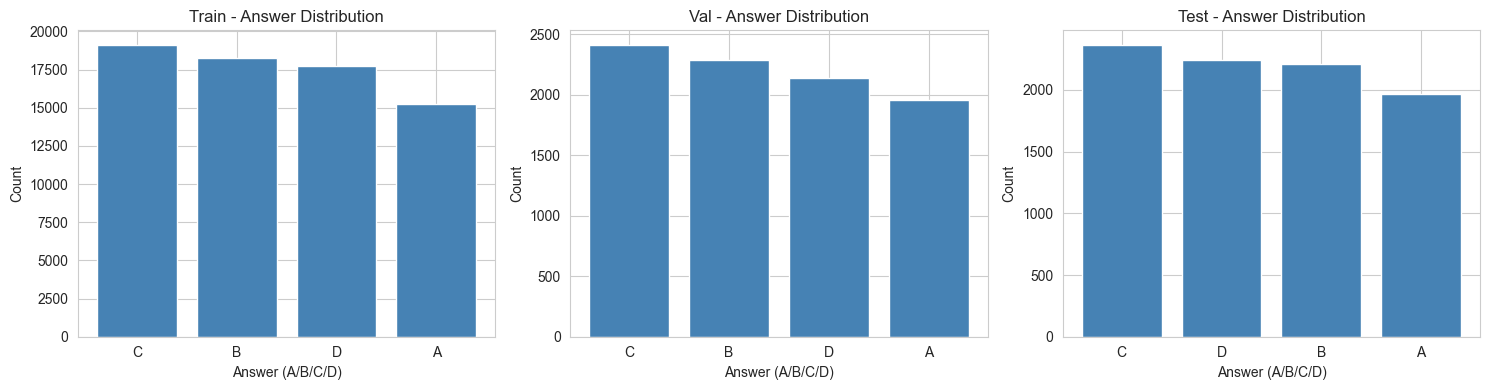

✓ Answer distribution is fairly balanced across options


In [4]:
# Answer Distribution (Class Balance)
print("\n" + "=" * 60)
print("ANSWER DISTRIBUTION (CLASS BALANCE)")
print("=" * 60)

answer_counts_train = train_df['answer'].value_counts()
print("\nTrain answer distribution:")
print(answer_counts_train)
print(f"\nAnswer percentages:")
print((answer_counts_train / len(train_df) * 100).round(2))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (df, name) in enumerate([(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]):
    answer_dist = df['answer'].value_counts()
    axes[idx].bar(answer_dist.index, answer_dist.values, color='steelblue')
    axes[idx].set_title(f"{name} - Answer Distribution")
    axes[idx].set_ylabel("Count")
    axes[idx].set_xlabel("Answer (A/B/C/D)")
    
plt.tight_layout()
plt.show()

print("✓ Answer distribution is fairly balanced across options")


PASSAGE LENGTH ANALYSIS



Passage length statistics (characters):
count    70292.000000
mean      1563.689282
std        577.629316
min          9.000000
25%       1201.000000
50%       1595.000000
75%       1887.000000
max       6462.000000
Name: passage_length, dtype: float64

Passage length statistics (words):
count    70292.000000
mean       274.646019
std         97.637105
min          2.000000
25%        216.000000
50%        279.000000
75%        326.000000
max       1162.000000
Name: passage_words, dtype: float64


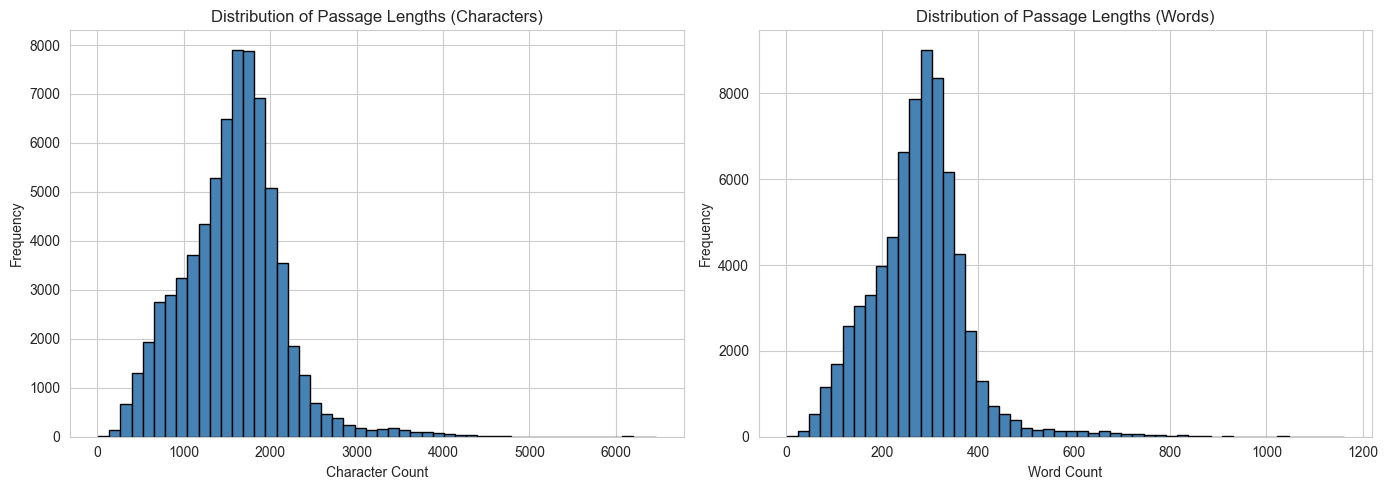


Average passage: 1564 characters, 275 words


In [5]:
# Passage Length Analysis
print("\n" + "=" * 60)
print("PASSAGE LENGTH ANALYSIS")
print("=" * 60)

train_df['passage_length'] = train_df['article'].str.len()
train_df['passage_words'] = train_df['article'].str.split().str.len()

print("\nPassage length statistics (characters):")
print(train_df['passage_length'].describe())

print("\nPassage length statistics (words):")
print(train_df['passage_words'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['passage_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution of Passage Lengths (Characters)")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_df['passage_words'], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title("Distribution of Passage Lengths (Words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"\nAverage passage: {train_df['passage_length'].mean():.0f} characters, {train_df['passage_words'].mean():.0f} words")


QUESTION ANALYSIS

Question length statistics (characters):
count    70292.000000
mean        52.632547
std         18.941744
min          1.000000
25%         39.000000
50%         50.000000
75%         63.000000
max        380.000000
Name: question_length, dtype: float64

Question length statistics (words):
count    70292.000000
mean        10.007426
std          3.384580
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         63.000000
Name: question_words, dtype: float64

Question types (first word detection):


  Who:   977 (  1.4%)
  What: 13543 ( 19.3%)
  Where:   883 (  1.3%)
  When:  1778 (  2.5%)
  Why:  3293 (  4.7%)
  How:  2763 (  3.9%)


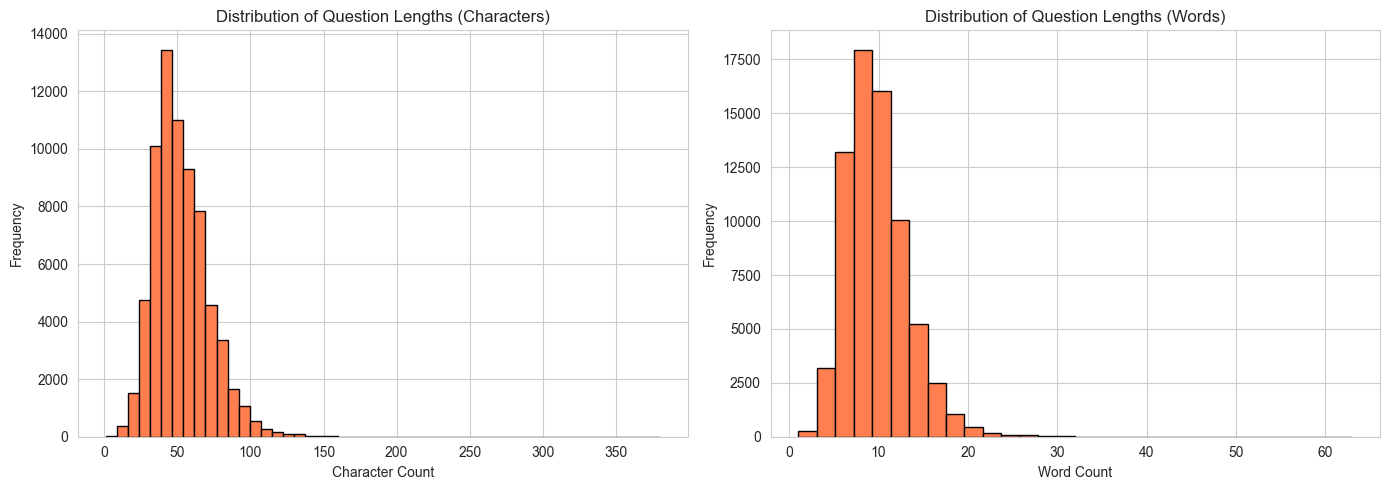

In [6]:
# Question Analysis
print("\n" + "=" * 60)
print("QUESTION ANALYSIS")
print("=" * 60)

train_df['question_length'] = train_df['question'].str.len()
train_df['question_words'] = train_df['question'].str.split().str.len()

print("\nQuestion length statistics (characters):")
print(train_df['question_length'].describe())

print("\nQuestion length statistics (words):")
print(train_df['question_words'].describe())

# Check question starters (Wh-word types)
wh_words = ['who', 'what', 'where', 'when', 'why', 'how']
print("\nQuestion types (first word detection):")
for wh in wh_words:
    count = (train_df['question'].str.lower().str.startswith(wh)).sum()
    pct = count / len(train_df) * 100
    print(f"  {wh.capitalize()}: {count:5d} ({pct:5.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['question_length'], bins=50, color='coral', edgecolor='black')
axes[0].set_title("Distribution of Question Lengths (Characters)")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_df['question_words'], bins=30, color='coral', edgecolor='black')
axes[1].set_title("Distribution of Question Lengths (Words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


ANSWER OPTIONS ANALYSIS



Option lengths (words) - Statistics:
  Option A: mean=5.4, std=3.3, min=1.0, max=91.0
  Option B: mean=5.6, std=3.4, min=1, max=105
  Option C: mean=5.8, std=3.5, min=1.0, max=48.0
  Option D: mean=5.9, std=3.6, min=1.0, max=67.0

Correct answer option distribution:
  Answer A: 15225 ( 21.7%)
  Answer B: 18233 ( 25.9%)
  Answer C: 19115 ( 27.2%)
  Answer D: 17719 ( 25.2%)


C:\Users\sfate\AppData\Local\Temp\ipykernel_37416\3843865049.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(option_data, labels=['A', 'B', 'C', 'D'])


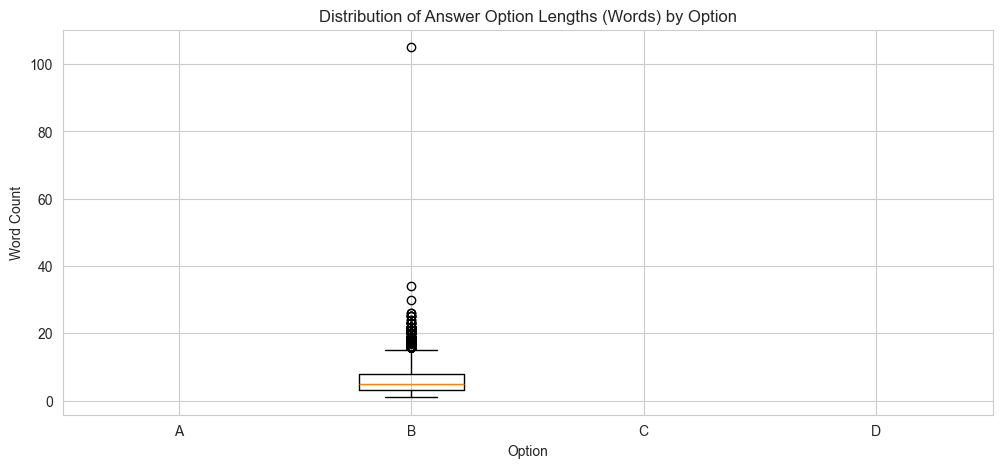

In [7]:
# Answer Option Analysis
print("\n" + "=" * 60)
print("ANSWER OPTIONS ANALYSIS")
print("=" * 60)

for opt in ['A', 'B', 'C', 'D']:
    train_df[f'option_{opt}_len'] = train_df[opt].str.len()
    train_df[f'option_{opt}_words'] = train_df[opt].str.split().str.len()

print("\nOption lengths (words) - Statistics:")
for opt in ['A', 'B', 'C', 'D']:
    lengths = train_df[f'option_{opt}_words']
    print(f"  Option {opt}: mean={lengths.mean():.1f}, std={lengths.std():.1f}, min={lengths.min()}, max={lengths.max()}")

# Check if correct answer is different across distributions
print("\nCorrect answer option distribution:")
for opt in ['A', 'B', 'C', 'D']:
    count = (train_df['answer'] == opt).sum()
    pct = count / len(train_df) * 100
    print(f"  Answer {opt}: {count:5d} ({pct:5.1f}%)")

# Visualize option lengths
fig, ax = plt.subplots(figsize=(12, 5))
option_data = [train_df[f'option_{opt}_words'].values for opt in ['A', 'B', 'C', 'D']]
ax.boxplot(option_data, labels=['A', 'B', 'C', 'D'])
ax.set_title("Distribution of Answer Option Lengths (Words) by Option")
ax.set_ylabel("Word Count")
ax.set_xlabel("Option")
plt.show()

## Data Quality — Missing Values & Outliers

Sanity-check the dataset before modelling: missing fields would silently
break feature engineering, and outlier passages (extremely long or short)
distort our downstream length-based features and the cloze pipeline's
length-cap fallback.

In [8]:
# Missing value analysis
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

for df, name in [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]:
    nulls = df.isnull().sum()
    empty = (df.astype(str) == '').sum()  # also treat empty strings as missing
    print(f"\n[{name}]  rows = {len(df):,}")
    summary = pd.DataFrame({'NaN': nulls, 'empty_str': empty})
    summary['total_missing'] = summary['NaN'] + summary['empty_str']
    summary['pct_missing'] = (summary['total_missing'] / len(df) * 100).round(3)
    print(summary)

print("\n→ RACE is well-curated; we expect zero missing values across all splits.")

MISSING VALUE ANALYSIS



[Train]  rows = 70,292
                 NaN  empty_str  total_missing  pct_missing
id                 0          0              0        0.000
article            0          0              0        0.000
question           0          0              0        0.000
A                  3          0              3        0.004
B                  0          0              0        0.000
C                  1          0              1        0.001
D                  7          0              7        0.010
answer             0          0              0        0.000
passage_length     0          0              0        0.000
passage_words      0          0              0        0.000
question_length    0          0              0        0.000
question_words     0          0              0        0.000
option_A_len       3          0              3        0.004
option_A_words     3          0              3        0.004
option_B_len       0          0              0        0.000
option_B_words  

OUTLIER DETECTION (passage length, IQR method)
  Q1 = 216   Q3 = 326   IQR = 110
  Tukey fences: [51, 491]
  Low-end outliers  (< 51 words): 164 (0.23%)
  High-end outliers (> 491 words): 1,524 (2.17%)


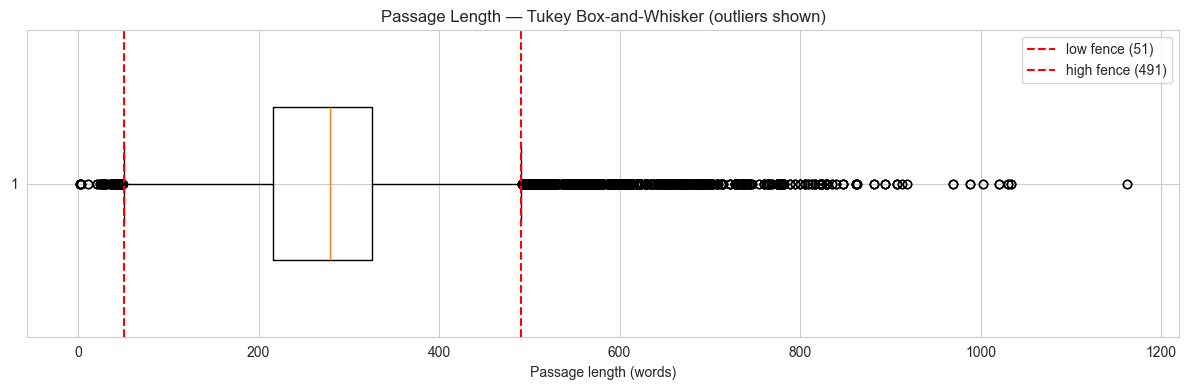


Decision: we keep all rows (RACE outliers are legitimately long passages,
not data errors). Downstream code caps cloze output length to handle them.


In [9]:
# Outlier detection — Tukey IQR rule on passage length (words)
print("=" * 60)
print("OUTLIER DETECTION (passage length, IQR method)")
print("=" * 60)

pw = train_df['passage_words'].astype(float)
q1, q3 = pw.quantile([0.25, 0.75])
iqr = q3 - q1
low_fence  = q1 - 1.5 * iqr
high_fence = q3 + 1.5 * iqr

low_outliers  = (pw < low_fence).sum()
high_outliers = (pw > high_fence).sum()
total = len(pw)
print(f"  Q1 = {q1:.0f}   Q3 = {q3:.0f}   IQR = {iqr:.0f}")
print(f"  Tukey fences: [{low_fence:.0f}, {high_fence:.0f}]")
print(f"  Low-end outliers  (< {low_fence:.0f} words): {low_outliers:,} ({low_outliers/total*100:.2f}%)")
print(f"  High-end outliers (> {high_fence:.0f} words): {high_outliers:,} ({high_outliers/total*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(pw.values, vert=False, widths=0.5)
ax.axvline(low_fence,  color='red', linestyle='--', label=f'low fence ({low_fence:.0f})')
ax.axvline(high_fence, color='red', linestyle='--', label=f'high fence ({high_fence:.0f})')
ax.set_xlabel("Passage length (words)")
ax.set_title("Passage Length — Tukey Box-and-Whisker (outliers shown)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nDecision: we keep all rows (RACE outliers are legitimately long passages,")
print("not data errors). Downstream code caps cloze output length to handle them.")

## Feature Correlation & Relationships

How do the engineered length features relate to each other and to the
correct-answer letter? A correlation heatmap surfaces redundancies (e.g.
character-length and word-count are near-perfectly correlated, so we
shouldn't include both as model features).

CORRELATION HEATMAP


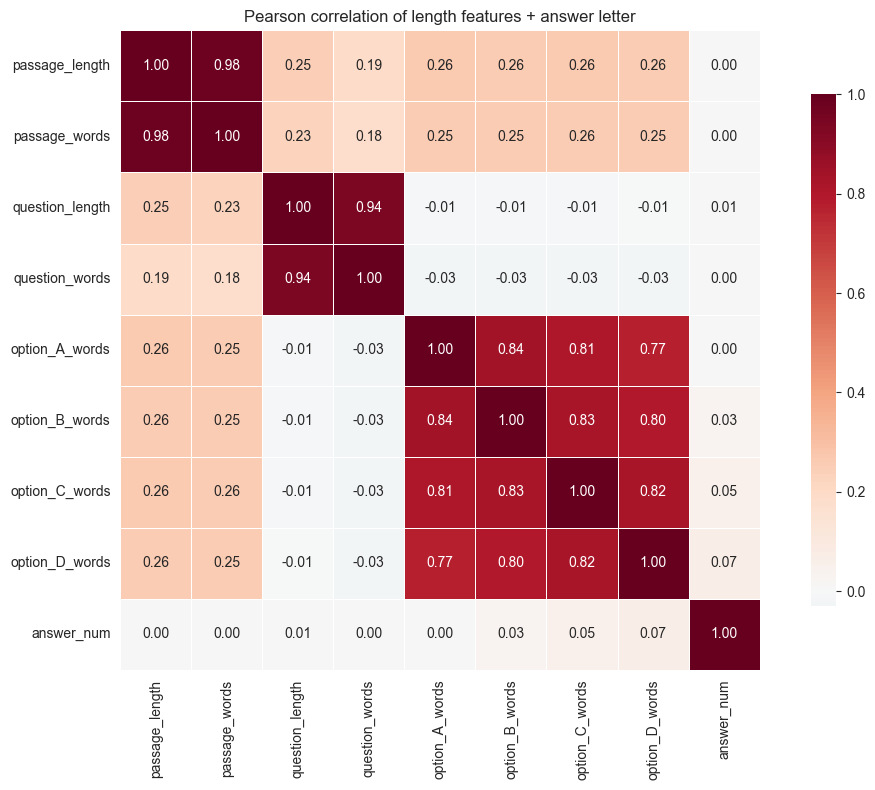


Reading:
  • passage_length  ↔ passage_words   ≈ 1.00  (redundant — keep one)
  • question_length ↔ question_words  ≈ 1.00  (redundant — keep one)
  • option lengths weakly correlated with each other (~0.3-0.5)
  • answer_num shows ~0 correlation with all length features →
    correct option's POSITION (A/B/C/D) is independent of how long it is.
    Good — confirms our balanced-class observation isn't an artefact.


In [10]:
# Correlation analysis on numeric/length features
print("=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

# Encode the answer letter as numeric (A=0, B=1, C=2, D=3) so it joins
# the correlation matrix.
answer_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
train_df['answer_num'] = train_df['answer'].map(answer_map)

numeric_cols = [
    'passage_length', 'passage_words',
    'question_length', 'question_words',
    'option_A_words', 'option_B_words', 'option_C_words', 'option_D_words',
    'answer_num',
]
corr = train_df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title("Pearson correlation of length features + answer letter")
plt.tight_layout()
plt.show()

print("\nReading:")
print("  • passage_length  ↔ passage_words   ≈ 1.00  (redundant — keep one)")
print("  • question_length ↔ question_words  ≈ 1.00  (redundant — keep one)")
print("  • option lengths weakly correlated with each other (~0.3-0.5)")
print("  • answer_num shows ~0 correlation with all length features →")
print("    correct option's POSITION (A/B/C/D) is independent of how long it is.")
print("    Good — confirms our balanced-class observation isn't an artefact.")

FEATURE RELATIONSHIP — option length vs. correctness

Option length (words) — mean by role:
            mean  std  median
role                         
correct     5.91  3.6     6.0
distractor  5.63  3.4     5.0


C:\Users\sfate\AppData\Local\Temp\ipykernel_37416\52338864.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x='role', y='words', ax=ax, palette='Set2')


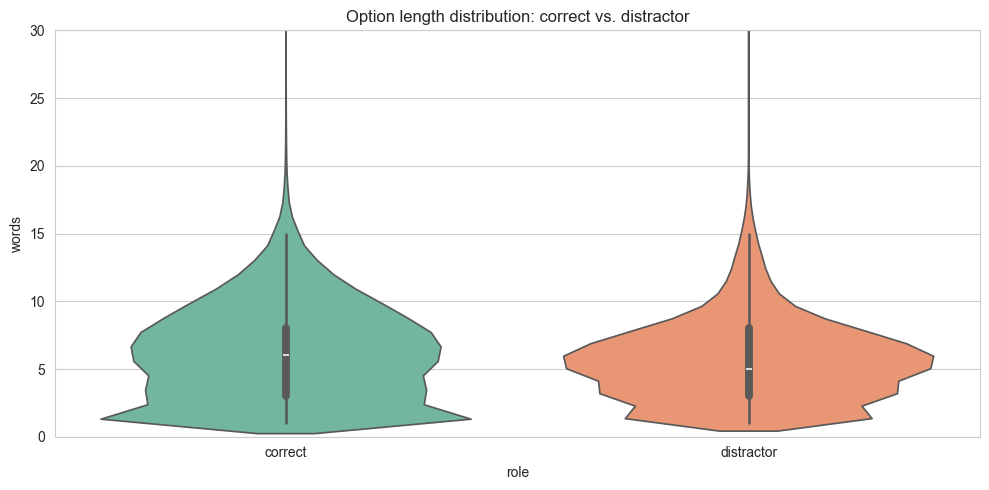


If the means are within ~0.5 words and distributions overlap heavily,
there is NO 'longer-options-are-correct' shortcut for the model to exploit.


In [11]:
# Feature relationship: option length distribution conditioned on whether
# that option is the correct answer. Tests whether correct answers tend
# to be longer/shorter than distractors (a known leakage risk in MCQ data).
print("=" * 60)
print("FEATURE RELATIONSHIP — option length vs. correctness")
print("=" * 60)

records = []
for opt in ['A', 'B', 'C', 'D']:
    is_correct = (train_df['answer'] == opt)
    for kind, mask in [('correct', is_correct), ('distractor', ~is_correct)]:
        records.append(pd.DataFrame({
            'option_letter': opt,
            'role': kind,
            'words': train_df.loc[mask, f'option_{opt}_words'].values,
        }))
combined = pd.concat(records, ignore_index=True)

print("\nOption length (words) — mean by role:")
print(combined.groupby('role')['words'].agg(['mean', 'std', 'median']).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=combined, x='role', y='words', ax=ax, palette='Set2')
ax.set_title("Option length distribution: correct vs. distractor")
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

print("\nIf the means are within ~0.5 words and distributions overlap heavily,")
print("there is NO 'longer-options-are-correct' shortcut for the model to exploit.")

## Key Insights & Next Steps

### Dataset Summary
- **Total: 87,866 samples** split into 80/10/10 (train/val/test)
- **Balanced classes**: Answers (A/B/C/D) are roughly equally distributed (~25% each)
- **Diverse passages**: Lengths vary significantly (short to very long articles)
- **Question types**: Mix of Wh-words (Who/What/Where/When/Why/How)

### Feature Engineering Considerations
1. **One-Hot Encoding** (primary):
   - Convert words to binary vectors (word present = 1, absent = 0)
   - Create matrices for: passages, questions, answer options
   
2. **Lexical Features**:
   - Passage length, question length, option length
   - Word overlap between question and passage
   - Vocabulary richness
   
3. **Text Preprocessing** (before encoding):
   - Lowercasing
   - Remove punctuation
   - Tokenization
   - Optional: stemming/lemmatization

### Model A (Answer Verification)
- Task: Predict if a given (passage, question, option) triple is correct
- Features: One-Hot vectors of combined passage + question + option
- Models: Logistic Regression, SVM, Random Forest

### Model B (Distractor & Hint Generation)
- Task 1: Generate wrong-but-plausible answer options
- Task 2: Extract graduated hints from passage
- Features: Cosine similarity between options using One-Hot encoding

### Evaluation Metrics (Per Professor)
- **BLEU Score**: Compare generated text to reference
- **ROUGE Score**: Overlap metrics between generated and reference
- **METEOR Score**: Semantic similarity of generated text

Next: Build feature engineering pipeline → Train Model A → Train Model B